# Exploratory Data Analysis (EDA)

## Objective

The goal of this analysis is to identify the factors that influence visa approval decisions and derive actionable business insights.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
df = pd.read_csv("../data/Visadataset.csv")

# Target Variable Analysis
## Business Question
### What percentage of visa applications are approved and denied?

In [7]:
df[["case_status"]].value_counts()

case_status
Certified      17018
Denied          8462
Name: count, dtype: int64

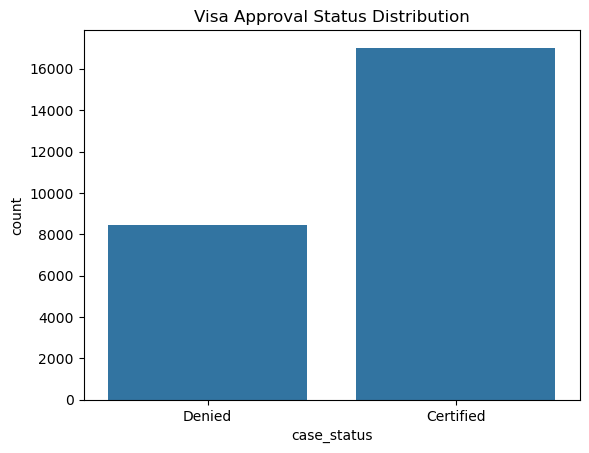

In [8]:
sns.countplot(
    data=df,
    x="case_status"
)

plt.title("Visa Approval Status Distribution")
plt.show()

### Insight

The majority of visa applications were approved, indicating a relatively high visa approval rate within the dataset.

# Continent Analysis
### Business Question
### Which continents submit the most applications?

In [9]:
df[["continent"]].value_counts()

continent    
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

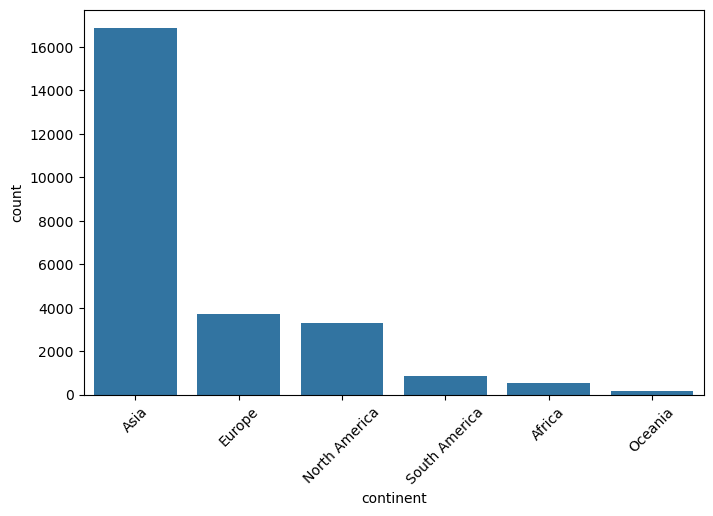

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="continent",
    order=df["continent"].value_counts().index
)

plt.xticks(rotation=45)
plt.show()

### Insight

Asia contributes the highest number of visa applications compared to other continents.

# Education vs Approval

In [11]:
pd.crosstab(df["education_of_employee"],
           df['case_status'])

case_status,Certified,Denied
education_of_employee,,
Bachelor's,6367,3867
Doctorate,1912,280
High School,1164,2256
Master's,7575,2059


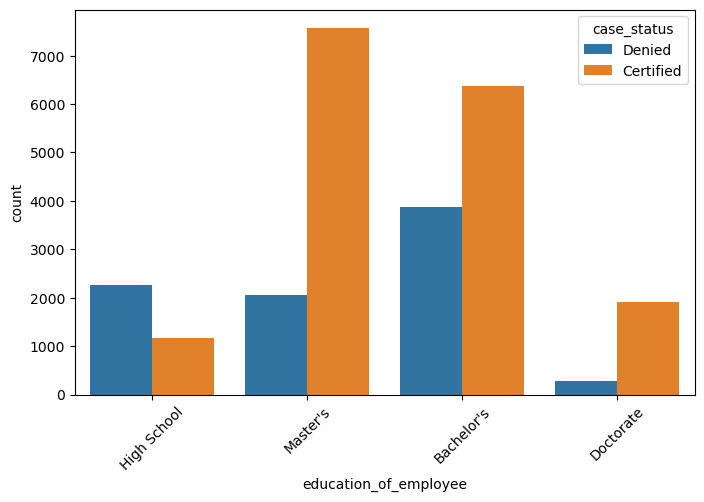

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(
    data = df,
    x='education_of_employee',
    hue='case_status'
)
plt.xticks(rotation=45)
plt.show()

### Insight

Applicants with higher educational qualifications tend to receive more approvals.

# Experience vs Approval

In [13]:
pd.crosstab(df['has_job_experience'],
           df['case_status'])

case_status,Certified,Denied
has_job_experience,,
N,5994,4684
Y,11024,3778


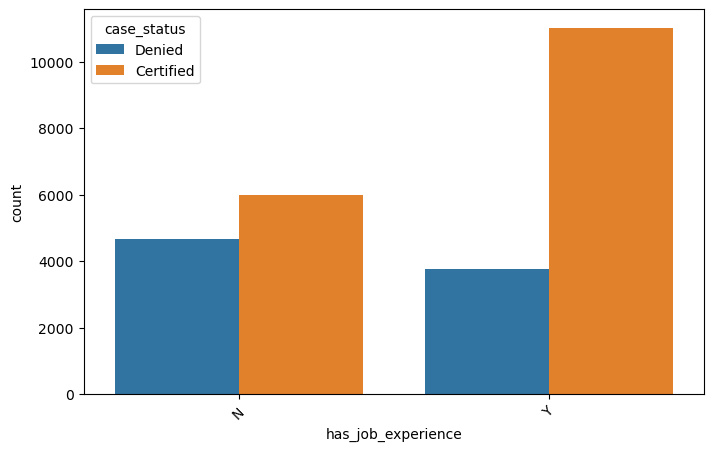

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,
              x='has_job_experience',
              hue='case_status'
             )
plt.xticks(rotation=45)
plt.show()

### Insight

Candidates with prior work experience appear to have higher approval rates.

# Job Training vs Approval

In [15]:
pd.crosstab(df['requires_job_training'],
            df['case_status']
           )

case_status,Certified,Denied
requires_job_training,,
N,15012,7513
Y,2006,949


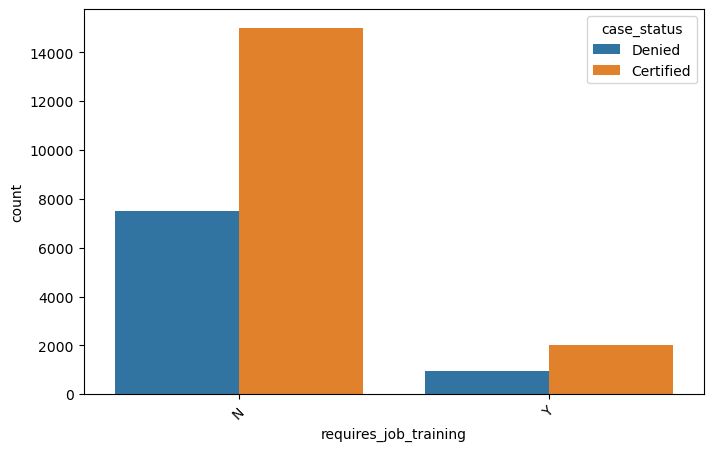

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data = df,
              x="requires_job_training",
              hue='case_status'
             )
plt.xticks(rotation=45)
plt.show()

# Wage Analysis

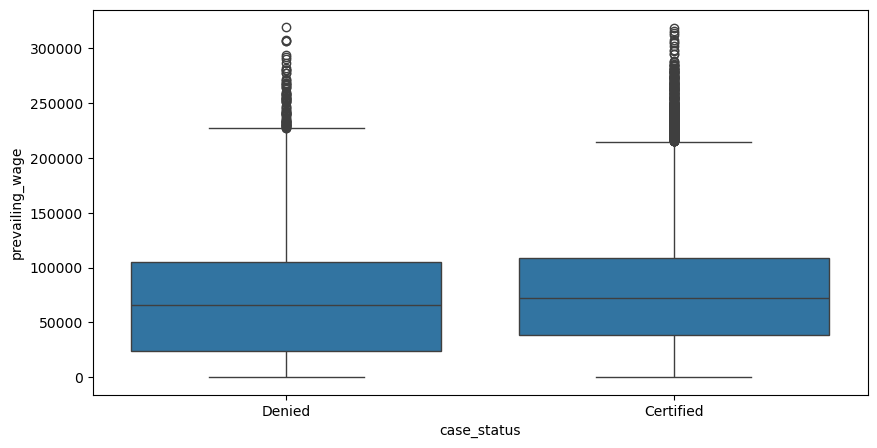

In [18]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data = df,
    x="case_status",
    y="prevailing_wage"
)
plt.show()

### Insight

Certified applications generally receive higher prevailing wages compared to denied applications.

# Full-Time Position Analysis

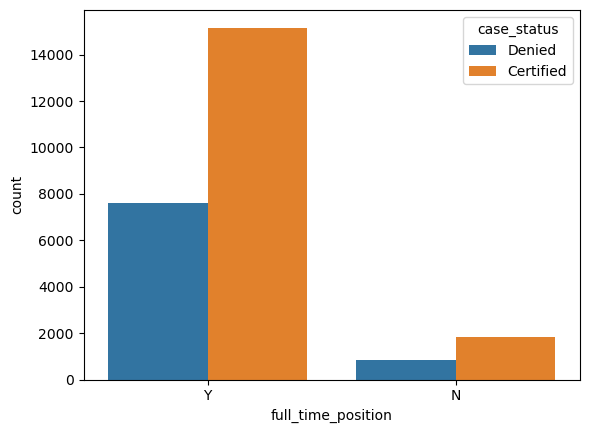

In [20]:
sns.countplot(data = df,
              x = "full_time_position",
              hue="case_status"
             )
plt.show()

## Insight

Full-time positions appear to have a higher likelihood of certification.

# Region Analysis

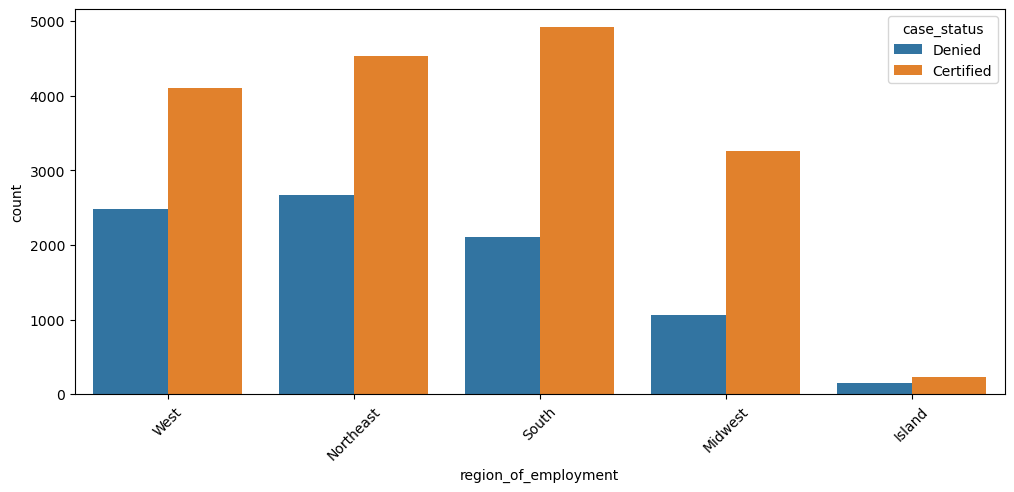

In [30]:
plt.figure(figsize=(12,5))
sns.countplot(data = df,
              x = "region_of_employment",
              hue="case_status"
             )
plt.xticks(rotation=45)
plt.show()

## Insight

Some employment regions contribute significantly more certified applications than others.

# Company Size Analysis

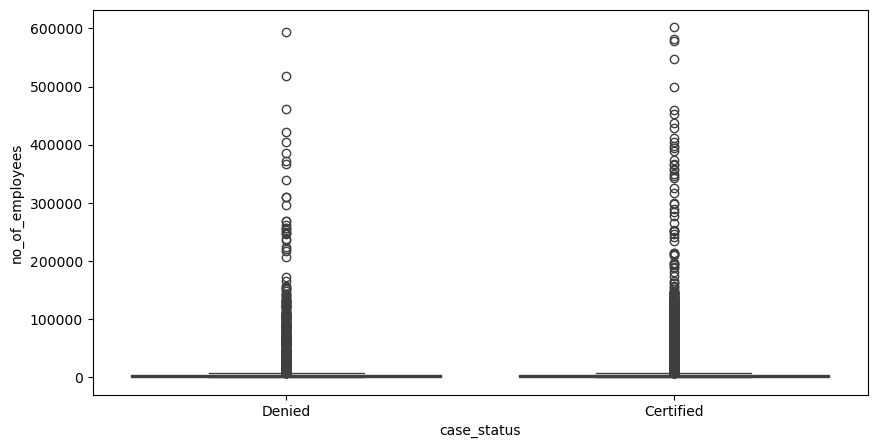

In [31]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="case_status",
    y="no_of_employees"
)

plt.show()

### Insight

Larger organizations tend to sponsor more certified visa applications.

# Correlation Analysis

In [25]:
from sklearn.preprocessing import LabelEncoder

# 1. Separate the column names into distinct lists
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(exclude='object').columns

# 2. Make your safe copy of the dataframe
temp = df.copy()

# 3. Loop through your categorical columns list
for col in cat_cols:
    temp[col] = LabelEncoder().fit_transform(temp[col])

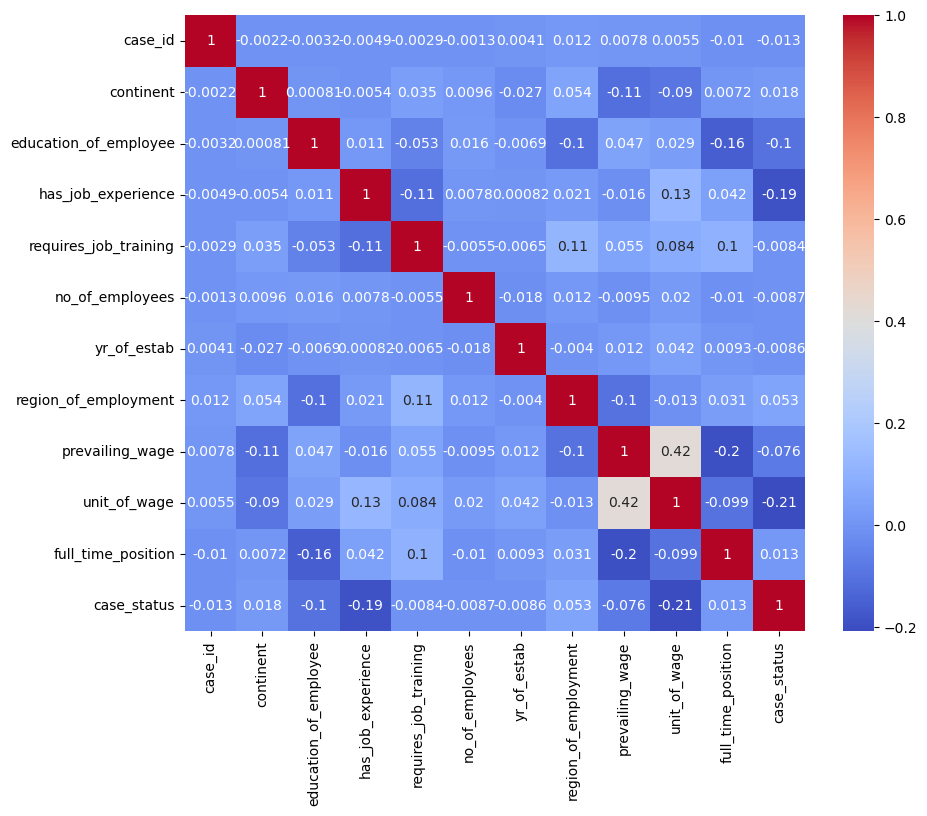

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(
    temp.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

# Business Insights Summary

# Key Business Insights

1. Most visa applications are certified.
2. Asia contributes the highest number of applications.
3. Higher educational qualifications improve certification chances.
4. Previous work experience positively influences certification.
5. Higher prevailing wages are associated with certification.
6. Full-time positions show stronger certification rates.
7. Certain employment regions dominate visa sponsorship activity.

# Business Recommendations

1. Focus on highly qualified applicants.
2. Offer competitive wage packages.
3. Prioritize experienced candidates.
4. Strengthen recruitment in regions with high certification rates.
5. Encourage full-time employment opportunities.